### Treatment Effect Estimation

In [2]:
import pandas as pd

#### load matched cohort 

In [6]:
df_matched = pd.read_csv("../data/matched_cohort.csv")
df_matched

,age,female,extranod,stage2,medwidsi_S,medwidsi_N,chemo,time,status
0,33.52,0,0,1,1,0,1,13.200,0
1,20.00,1,0,1,1,0,0,0.500,1
2,19.00,1,1,1,0,0,1,13.800,0
3,44.00,1,0,0,0,1,0,23.200,0
4,21.25,1,0,1,0,0,1,15.500,0
...,...,...,...,...,...,...,...,...,...
781,31.00,1,0,1,0,1,0,29.600,0
782,43.00,0,0,1,0,1,1,26.300,0
783,31.00,1,0,1,1,0,0,16.400,0
784,31.00,0,0,1,0,1,1,20.100,0


In [7]:
from pytmle import PyTMLE

target_times = [5.0, 10.0, 15.0, 20.0, 25.0, 30.0]

tmle = PyTMLE(df_matched, 
              col_event_times="time", 
              col_event_indicator="status", 
              col_group="chemo", 
              target_times=target_times, 
              g_comp=True,
              evalues_benchmark=False)

tmle.fit(save_models=True, 
         bootstrap=False, 
         n_jobs=-1)

/home/aweller/r4r-training/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Estimating propensity scores...
Estimating hazards and event-free survival...
Estimating censoring survival...


/home/aweller/r4r-training/.venv/lib/python3.12/site-packages/pytmle/initial_estimates_default_models.py:37: UserWarning: Default DeepHit model not available: No module named 'torch'. Will only cross-fit Cox PH and random survival forest.
  warnings.warn(


Starting TMLE update loop...
TMLE converged at step 56.


(<Figure size 1400x700 with 2 Axes>,
 array([<Axes: title={'center': 'Event 1'}, xlabel='Time', ylabel='Predicted Risk'>,
        <Axes: title={'center': 'Event 2'}, xlabel='Time', ylabel='Predicted Risk'>],
       dtype=object))

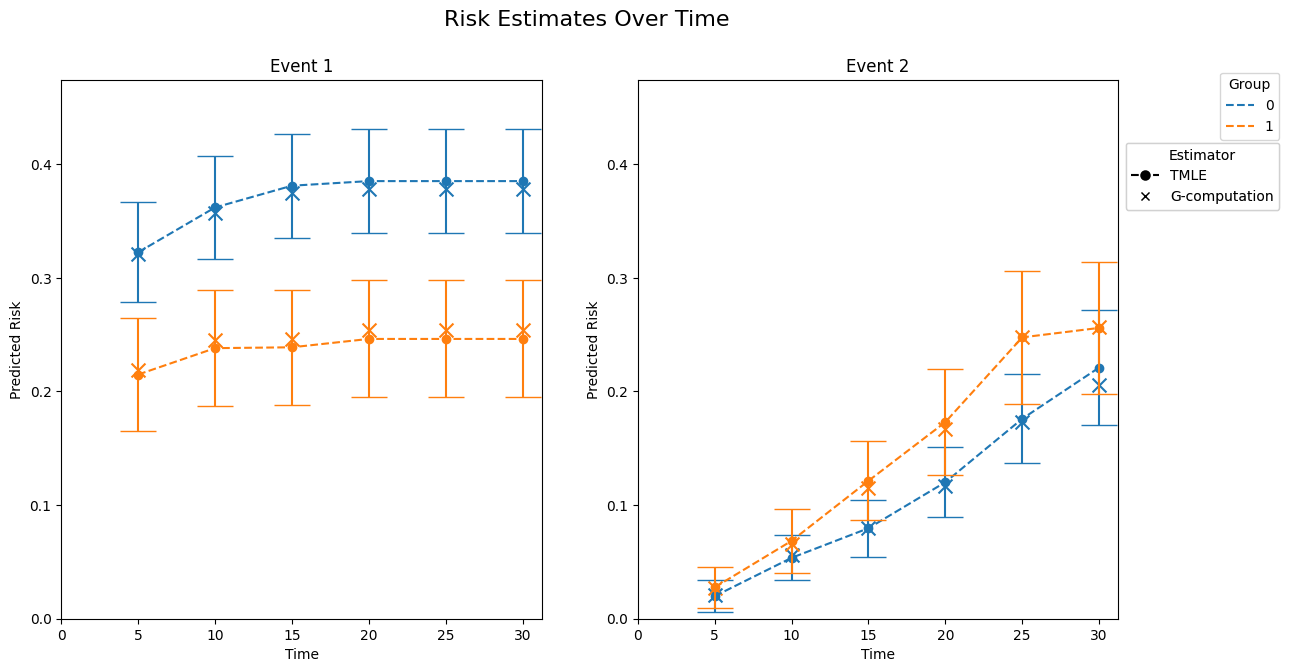

In [8]:
tmle.plot(g_comp=True, use_bootstrap=False)